**Trabajo Práctico 1: Regresión**

## **Exploración de Datos**
### **Carga del Dataset y Corrección de Datos**
Para comenzar, cargamos el dataset `casas_dev.csv` y exploramos sus primeras filas para entender su estructura.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/casas_dev.csv")
df.head()

,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
0,635.0,sqft,1,0,18.0,546.0,40.679064,-74.007844,2.0
1,1098.0,sqft,0,0,9.0,759.0,40.712839,-73.967750,3.0
2,667.0,sqft,0,0,7.0,464.0,40.669863,-74.029414,2.0
3,127.0,m2,1,1,16.0,251.0,-34.600437,-58.415266,4.0
4,1378.0,sqft,0,0,8.0,963.0,40.722322,-73.983229,4.0



### **Conversión de Unidades**
El dataset contiene valores de área en diferentes unidades (`m2` y `sqft`)


In [2]:
df.loc[df['area_units'] == 'sqft', 'area'] *= 0.092903
df.drop(columns=['area_units'], inplace=True)

miramos las distribuciones de las variables, y como son sus valores

In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      900 non-null    float64
 1   is_house  900 non-null    int64  
 2   has_pool  900 non-null    int64  
 3   age       770 non-null    float64
 4   price     900 non-null    float64
 5   lat       900 non-null    float64
 6   lon       900 non-null    float64
 7   rooms     828 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 56.4 KB


,area,is_house,has_pool,age,price,lat,lon,rooms
count,900.000000,900.000000,900.000000,770.000000,900.000000,900.000000,900.000000,828.000000
mean,94.794747,0.418889,0.144444,10.212987,466.197778,1.966225,-65.967203,2.737923
std,30.220560,0.493651,0.351735,4.773010,347.122903,37.661269,7.813671,0.948574
min,40.000000,0.000000,0.000000,1.000000,65.000000,-34.686302,-74.058238,1.000000
25%,74.000000,0.000000,0.000000,6.250000,178.750000,-34.605803,-74.005566,2.000000
50%,92.995903,0.000000,0.000000,11.000000,323.500000,-34.529704,-58.459293,3.000000
75%,111.264314,1.000000,0.000000,14.000000,712.500000,40.709819,-58.379873,3.000000
max,237.000000,1.000000,1.000000,20.000000,1992.000000,40.764550,-58.295919,5.000000



### **Visualización de la Distribución de los Datos**
Graficamos histogramas y scatterplots para analizar las relaciones entre variables.


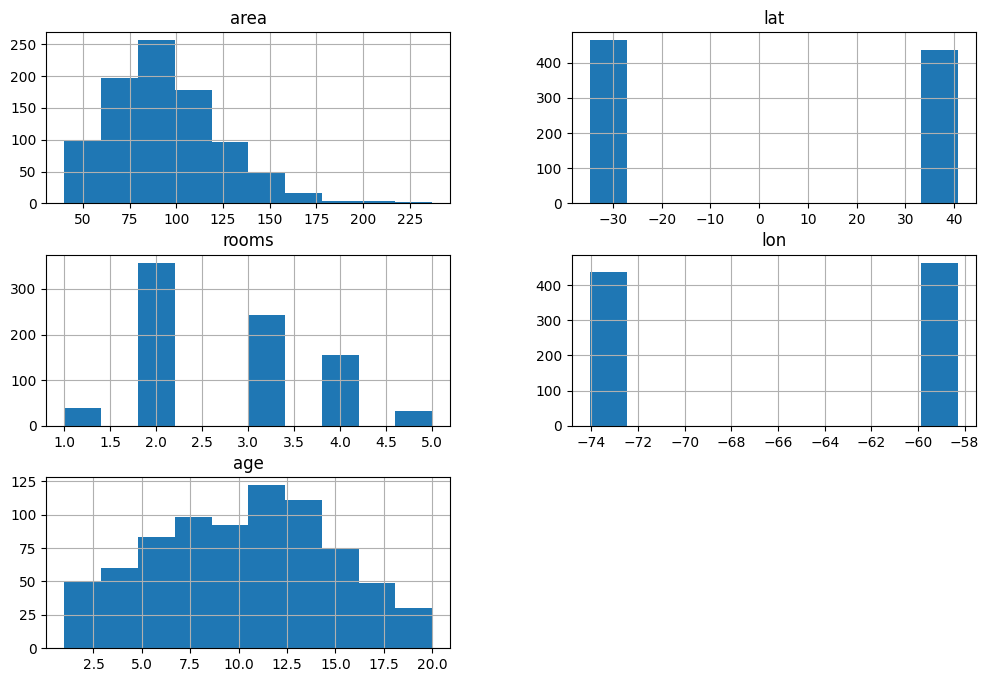

In [4]:
# Histogramas de area, age, price y rooms
df[['area', 'lat', 'rooms', 'lon', 'age']].hist(figsize=(12, 8))
plt.show()

parece haber una relacion entre area y rooms, ademas vemos que parece haber dos clusters segun lat y lon
vamos a ver estar relaciones. ademas teniendo doss variables booleaneas vemos como estas afectan en otros features

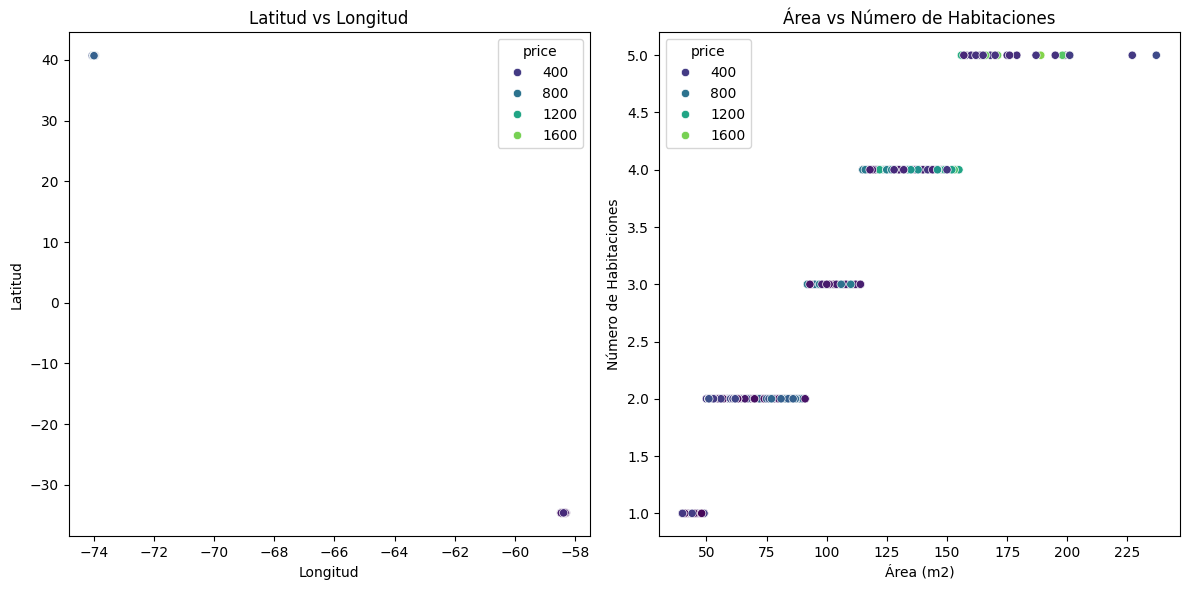

In [5]:
# Graficos de scatter para lat vs lon y area vs rooms
plt.figure(figsize=(12, 6))

# lat vs lon
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='lon', y='lat', hue='price', palette='viridis')
plt.title('Latitud vs Longitud')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# area vs rooms
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='area', y='rooms', hue='price', palette='viridis')
plt.title('Área vs Número de Habitaciones')
plt.xlabel('Área (m2)')
plt.ylabel('Número de Habitaciones')

plt.tight_layout()
plt.show()

podemos ver una clara relacion entre area y numero de habitaciones, y como vimos anes, rooms tienen nans. podemos inferirnos con esta informacion

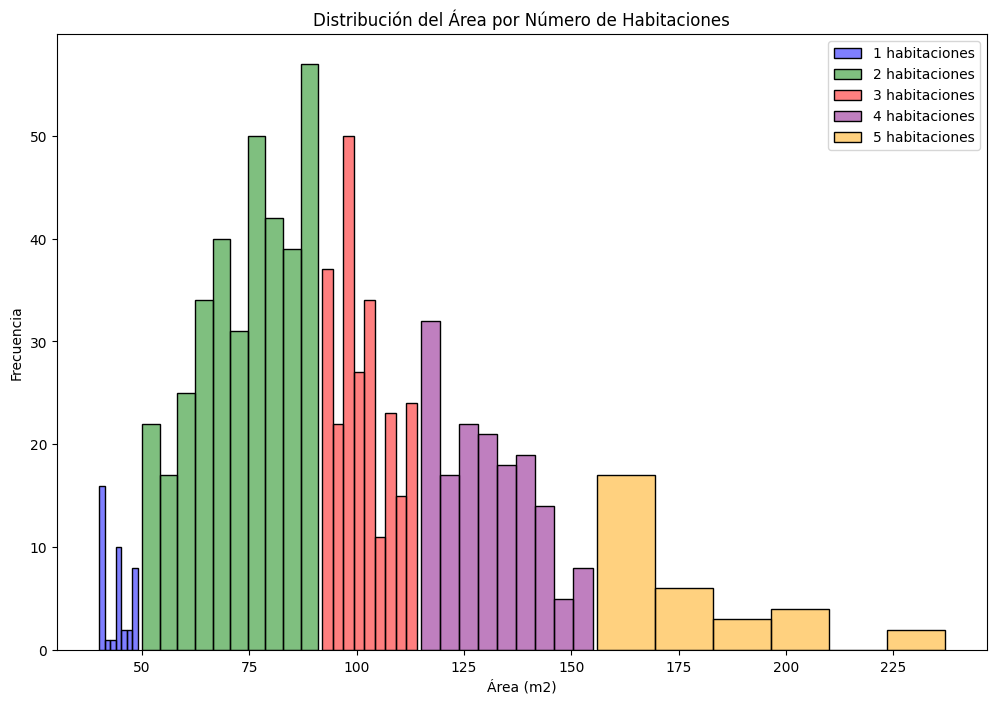

In [6]:
# Crear la figura
plt.figure(figsize=(12, 8))

# Definir colores y transparencias
colors = ['blue', 'green', 'red', 'purple', 'orange']
intervals = []

# Graficar histogramas para cada número de habitaciones
for room, color in zip(range(1, 6), colors):
    subset = df[df['rooms'] == room]
    intervals.append((subset['area'].min(), subset['area'].max()))
    sns.histplot(subset['area'], color=color, label=f'{room} habitaciones', alpha=0.5, kde=False)

# Configurar el título y etiquetas
plt.title('Distribución del Área por Número de Habitaciones')
plt.xlabel('Área (m2)')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()


tenemos intervalos muy marcados de cantidad de habitaciones

In [7]:
# Función para asignar el número de habitaciones basado en el área
def assign_rooms(area, intervals):
    for i, (min_val, max_val) in enumerate(intervals):
        if min_val <= area <= max_val:
            return i + 1
    return np.nan

# Aplicar la función a las filas con rooms como NaN
df.loc[df['rooms'].isna(), 'rooms'] = df.loc[df['rooms'].isna(), 'area'].apply(assign_rooms, intervals=intervals)

# Mostrar las primeras filas para verificar
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      900 non-null    float64
 1   is_house  900 non-null    int64  
 2   has_pool  900 non-null    int64  
 3   age       770 non-null    float64
 4   price     900 non-null    float64
 5   lat       900 non-null    float64
 6   lon       900 non-null    float64
 7   rooms     900 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 56.4 KB


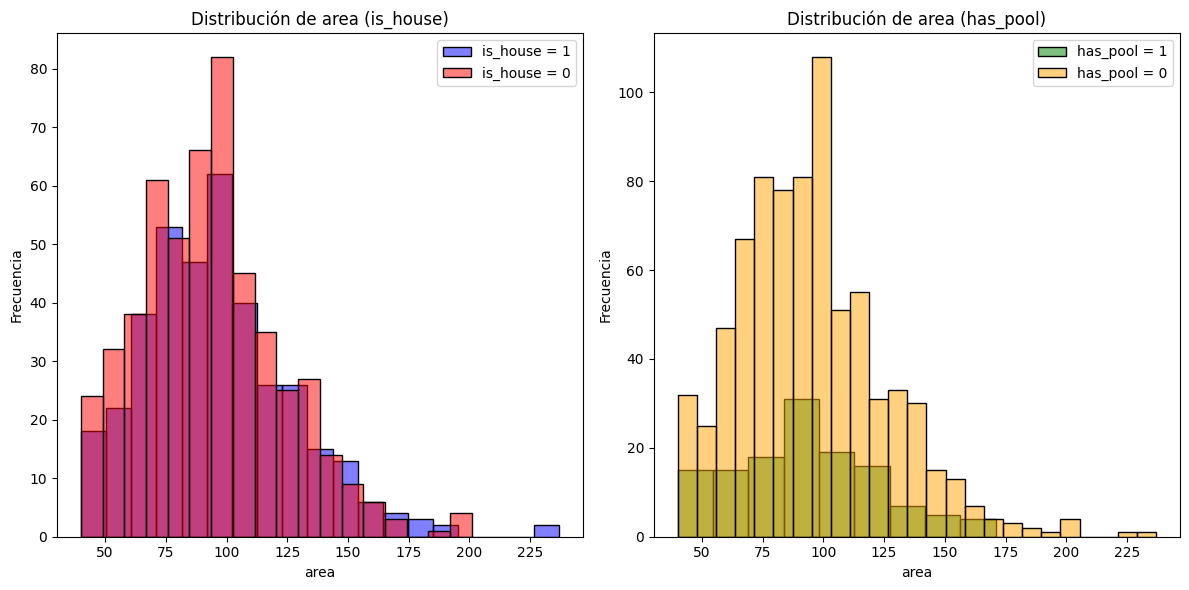

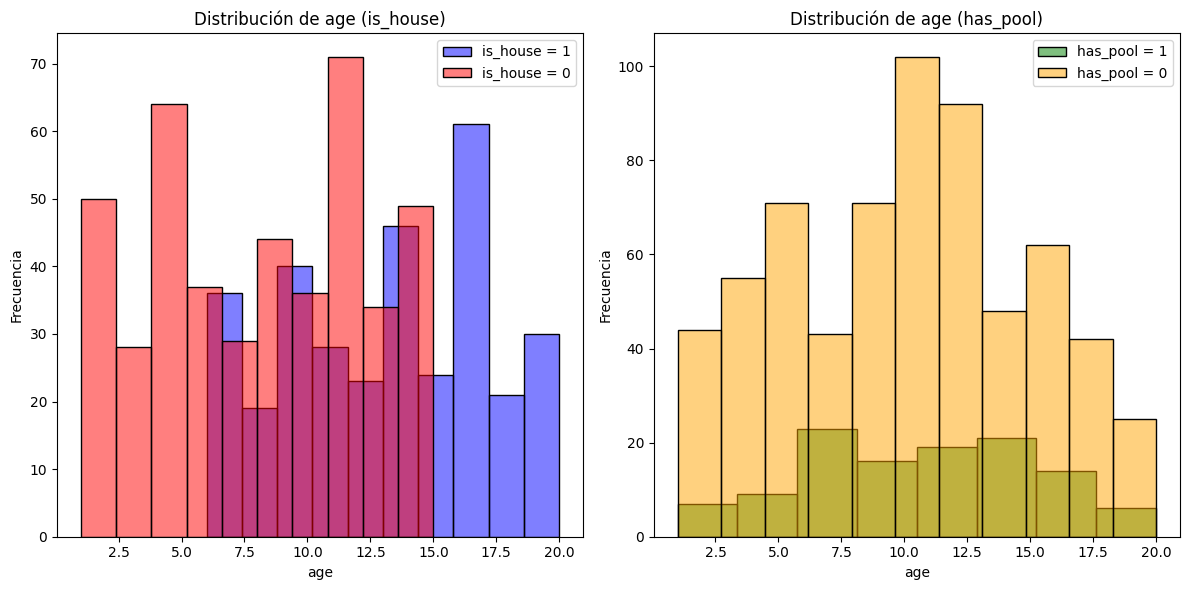

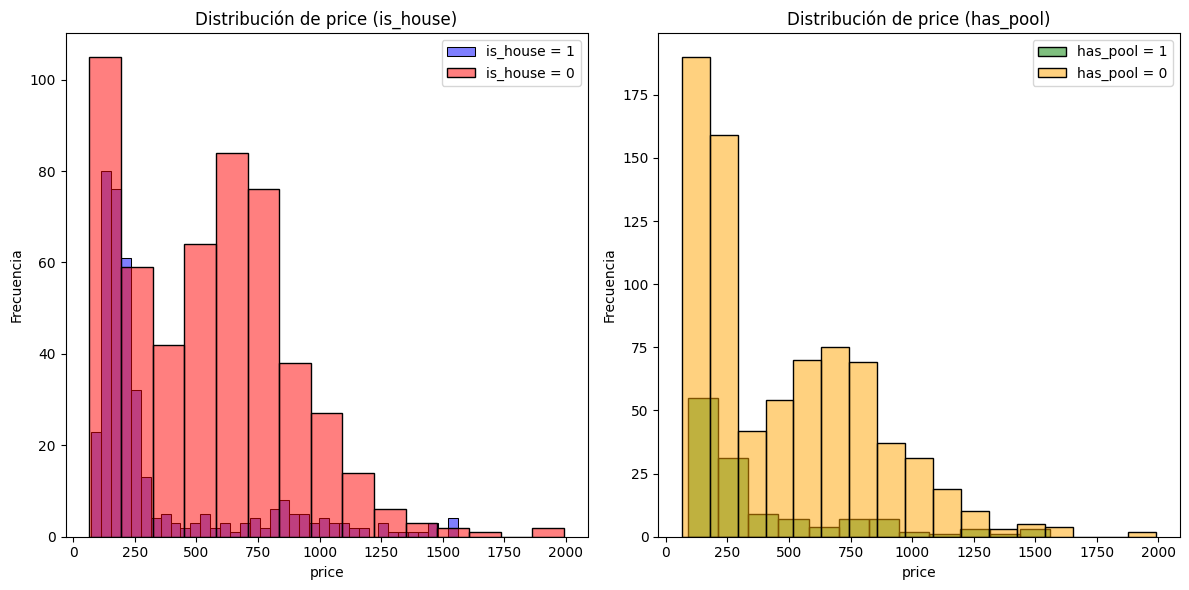

In [8]:
# Graficos de scatter para is_house y has_pool
features = ['area', 'age', 'price']

for feature in features:
    plt.figure(figsize=(12, 6))

    # is_house
    plt.subplot(1, 2, 1)
    sns.histplot(df[df['is_house'] == 1][feature], color='blue', label='is_house = 1', alpha=0.5)
    sns.histplot(df[df['is_house'] == 0][feature], color='red', label='is_house = 0', alpha=0.5)
    plt.title(f'Distribución de {feature} (is_house)')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()

    # has_pool
    plt.subplot(1, 2, 2)
    sns.histplot(df[df['has_pool'] == 1][feature], color='green', label='has_pool = 1', alpha=0.5)
    sns.histplot(df[df['has_pool'] == 0][feature], color='orange', label='has_pool = 0', alpha=0.5)
    plt.title(f'Distribución de {feature} (has_pool)')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()

    plt.tight_layout()
    plt.show()


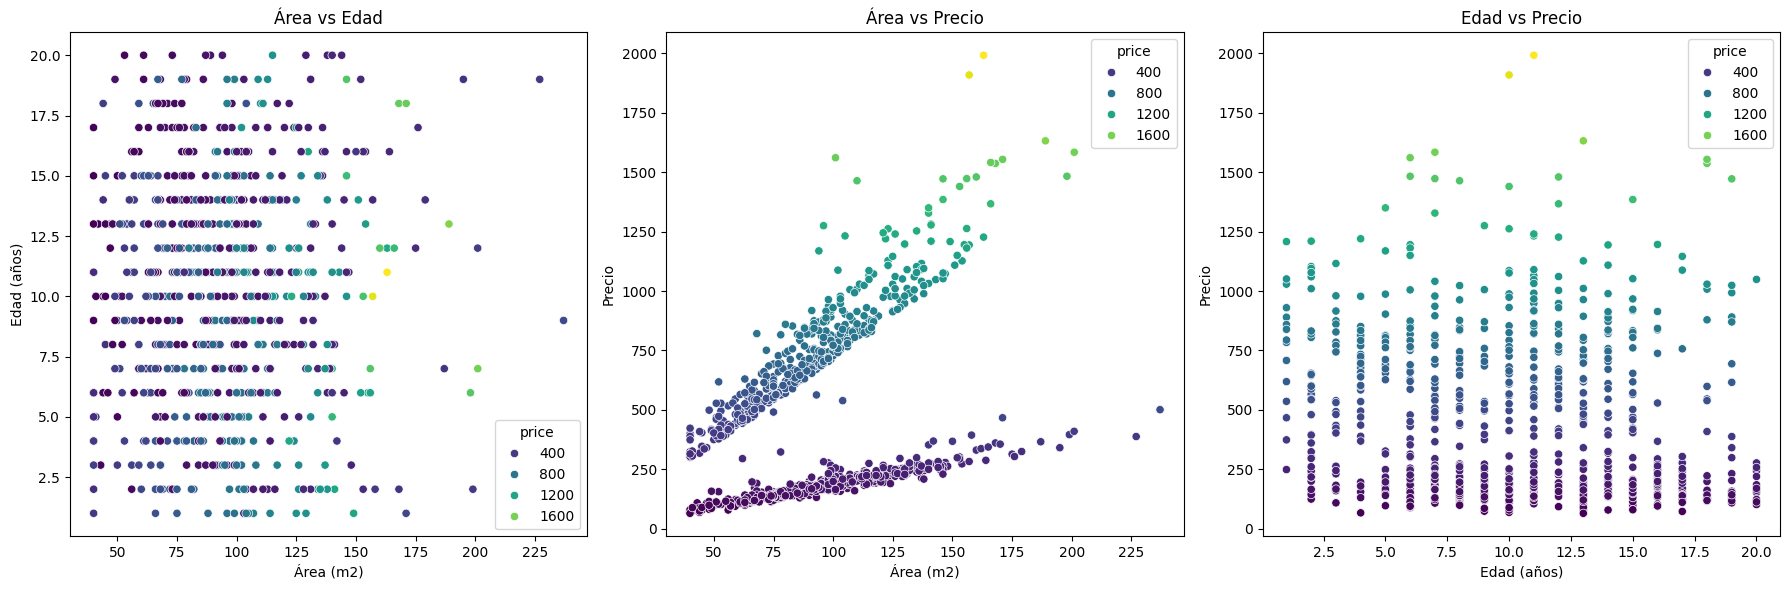

In [9]:

# Graficos de scatter para area vs age, area vs price, age vs price
plt.figure(figsize=(18, 6))

# area vs age
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='area', y='age', hue='price', palette='viridis')
plt.title('Área vs Edad')
plt.xlabel('Área (m2)')
plt.ylabel('Edad (años)')

# area vs price
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='area', y='price', hue='price', palette='viridis')
plt.title('Área vs Precio')
plt.xlabel('Área (m2)')
plt.ylabel('Precio')

# age vs price
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='age', y='price', hue='price', palette='viridis')
plt.title('Edad vs Precio')
plt.xlabel('Edad (años)')
plt.ylabel('Precio')

plt.tight_layout()
plt.show()

quiero encontrar alguna feature que se relacione con age para llenar esta feature. no uso area porque se que esta esta relacinada con rooms y rooms es mas facil de vizualizar, no uso price para no hacer un leak

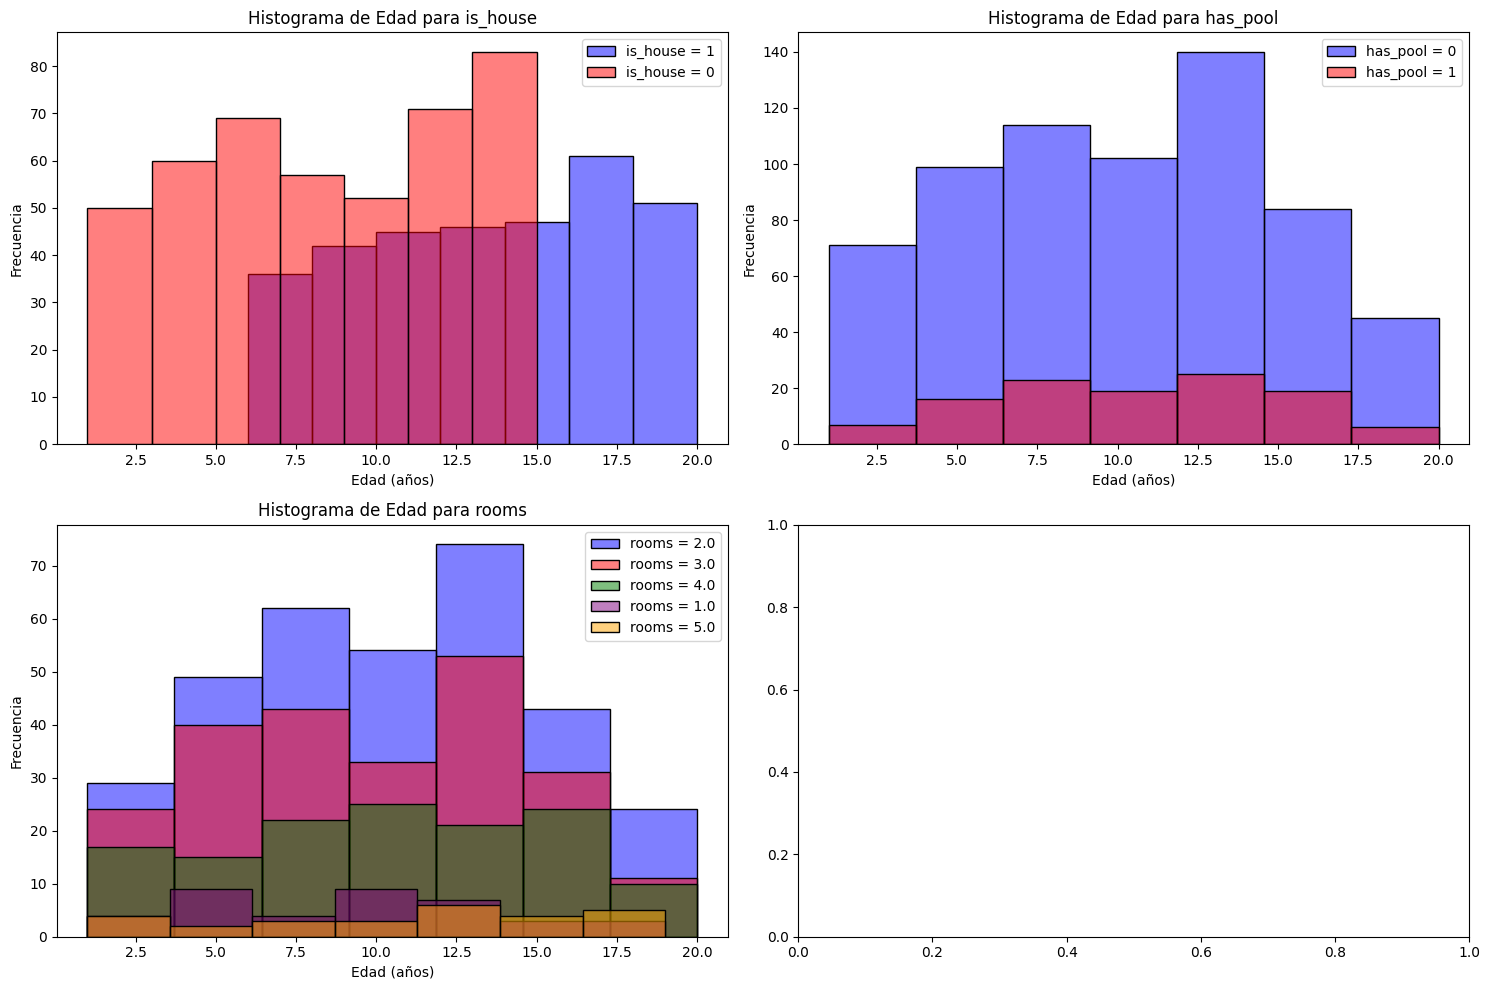

In [10]:
features = ['is_house', 'has_pool', 'rooms']
colors = ['blue', 'red', 'green', 'purple', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), features):
    unique_values = df[feature].dropna().unique()
    
    for value, color in zip(unique_values, colors):
        subset = df[df[feature] == value]
        sns.histplot(subset['age'].dropna(), color=color, label=f'{feature} = {value}', alpha=0.5, kde=False, bins=7, ax=ax)
    
    ax.set_title(f'Histograma de Edad para {feature}')
    ax.set_xlabel('Edad (años)')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()


a variable que mas separa age es is_house lo cual tiene sentido pensar que no hay edificios tan viejos.

In [11]:
# Calcular la mediana de 'age' para cada subset
median_age_house = df[df['is_house'] == 1]['age'].median()
median_age_not_house = df[df['is_house'] == 0]['age'].median()

# Imputar los valores faltantes de 'age' según el valor de 'is_house'
df.loc[(df['is_house'] == 1) & (df['age'].isna()), 'age'] = median_age_house
df.loc[(df['is_house'] == 0) & (df['age'].isna()), 'age'] = median_age_not_house

# Mostrar las primeras filas para verificar
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      900 non-null    float64
 1   is_house  900 non-null    int64  
 2   has_pool  900 non-null    int64  
 3   age       900 non-null    float64
 4   price     900 non-null    float64
 5   lat       900 non-null    float64
 6   lon       900 non-null    float64
 7   rooms     900 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 56.4 KB


In [12]:
df.describe()

,area,is_house,has_pool,age,price,lat,lon,rooms
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,94.794747,0.418889,0.144444,10.165556,466.197778,1.966225,-65.967203,2.731111
std,30.220560,0.493651,0.351735,4.511058,347.122903,37.661269,7.813671,0.942702
min,40.000000,0.000000,0.000000,1.000000,65.000000,-34.686302,-74.058238,1.000000
25%,74.000000,0.000000,0.000000,7.000000,178.750000,-34.605803,-74.005566,2.000000
50%,92.995903,0.000000,0.000000,10.000000,323.500000,-34.529704,-58.459293,3.000000
75%,111.264314,1.000000,0.000000,13.000000,712.500000,40.709819,-58.379873,3.000000
max,237.000000,1.000000,1.000000,20.000000,1992.000000,40.764550,-58.295919,5.000000


In [13]:
# Separar la variable objetivo (price)
X = df.drop(columns=["price"])
y = df["price"].values

# Columnas a estandarizar
standardize_cols = ["area", "age", "rooms"]

# Columnas binarias (no se normalizan)
binary_cols = ["is_house", "has_pool", "barrio"]

# Dividir en train (80%) y validation (20%)
train_size = int(0.8 * len(X))
X_train, X_val = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Calcular la mediana y std solo en el conjunto de entrenamiento
train_median = X_train[standardize_cols].median()
train_std = X_train[standardize_cols].std()

# Aplicar normalización usando la mediana y std del train
X_train[standardize_cols] = (X_train[standardize_cols] - train_median) / train_std
X_val[standardize_cols] = (X_val[standardize_cols] - train_median) / train_std

# Función para desnormalizar coeficientes después de entrenar un modelo
def desnormalizar_coeficientes(beta_normalizado):
    beta_original = beta_normalizado.copy()
    for col in standardize_cols:
        beta_original[col] *= train_std[col]
    return beta_original

C:\Users\elian\AppData\Local\Temp\ipykernel_13804\1260123118.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[standardize_cols] = (X_train[standardize_cols] - train_median) / train_std
C:\Users\elian\AppData\Local\Temp\ipykernel_13804\1260123118.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[standardize_cols] = (X_val[standardize_cols] - train_median) / train_std


In [14]:
import sys 
import os
sys.path.append(os.path.abspath('..'))
from src import models

In [15]:
# Crear y entrenar modelo
model = models.LinearRegression(X_train['area'], y_train)
model.train_pseudoinverse()

# Evaluación del modelo
y_pred = model.predict(X_train['area'])
error = models.mse(y_train, y_pred)
print("Error cuadrático medio en train:", error)

# Evaluación del modelo
y_pred = model.predict(X_val['area'])
error = models.mse(y_val, y_pred)
print("Error cuadrático medio en validación:", error)

# Imprimir coeficientes
model.print_coefficients(X_train.columns)


Error cuadrático medio en train: 143495.81389362772
Error cuadrático medio en validación: 124060.41114036975
Intercepto: 457.0310225320354
area: 137.55158616654384


In [16]:
X_train.columns

Index(['area', 'is_house', 'has_pool', 'age', 'lat', 'lon', 'rooms'], dtype='object')

In [17]:
# Crear y entrenar modelo
model1 = models.LinearRegression(X_train[['area', 'is_house', 'has_pool', 'age', 'lat', 'lon']], y_train)
model1.train_pseudoinverse()

# Evaluación del modelo
y_pred = model1.predict(X_train[['area', 'is_house', 'has_pool', 'age', 'lat', 'lon']])
error = models.mse(y_train, y_pred)
print("Error cuadrático medio en train:", error)

# Evaluación del modelo
y_pred = model1.predict(X_val[['area', 'is_house', 'has_pool', 'age', 'lat', 'lon']])
error = models.mse(y_val, y_pred)
print("Error cuadrático medio en validación:", error)

# Imprimir coeficientes
model1.print_coefficients(X_train.columns)

Error cuadrático medio en train: 233280.75934246025
Error cuadrático medio en validación: 203064.6112670891
Intercepto: 7396.979707150909
area: 151.95883328602537
is_house: 80.43546653328073
has_pool: 52.65546562400088
age: -13.837898474736265
lat: 30.544241984686025
lon: 106.76239490538848


In [18]:
# Cargar el nuevo dataset
df_amanda = pd.read_csv("../data/raw/vivienda_Amanda.csv")

# Preprocesar los datos de manera similar al conjunto de entrenamiento
df_amanda.loc[df_amanda['area_units'] == 'sqft', 'area'] *= 0.092903
df_amanda.drop(columns=['area_units'], inplace=True)

# Normalizar las columnas de la misma manera que el conjunto de entrenamiento
df_amanda[standardize_cols] = (df_amanda[standardize_cols] - train_median) / train_std

# Seleccionar las columnas necesarias para la predicción
X_amanda = df_amanda[['area', 'is_house', 'has_pool', 'age', 'lat', 'lon']]

# Hacer las predicciones
y_amanda_pred = model1.predict(X_amanda)

# Agregar las predicciones al dataframe original
df_amanda['predicted_price'] = y_amanda_pred

# Mostrar las primeras filas con las predicciones
print(df_amanda.head())

       area  is_house  has_pool     age        lat        lon  rooms  \
0  0.399289         0         0  0.2208  40.675423 -74.012999    0.0   

   predicted_price  
0        795.19465  


In [19]:
# Calcular el valor por metro cuadrado
casas = df[df['is_house'] == 1]
valor_promedio_m2_casa = (casas['price'] / casas['area']).mean()

print(f"El valor promedio por metro cuadrado de una casa es: {valor_promedio_m2_casa:.2f}")

El valor promedio por metro cuadrado de una casa es: 3.58


In [20]:
# Entrenar la regresión lineal
model = models.LinearRegression(X_train, y_train)
model.train_pseudoinverse()  # También se puede usar train_gradient_descent()
model.print_coefficients(["has_pool"])

# Obtener coeficientes desnormalizados
coef_normalizados = model.coef.flatten()
coef_desnormalizados = coef_normalizados.copy()

for i, col in enumerate(standardize_cols):
    coef_desnormalizados[i + 1] *= train_std[col]  # Desnormalizar características

# Impacto de la pileta en el precio
impacto_pileta = coef_desnormalizados[list(X_train.columns).index("has_pool") + 1]

print(f"Impacto estimado de construir una pileta en el precio: ${impacto_pileta:.2f}")

Intercepto: 7331.5661210186045
has_pool: 134.4070921813021
Impacto estimado de construir una pileta en el precio: $48.40


volviendo al grafioc tambien vimos que efectvamente hay dos clusters, podriamos hacer un algortimo de kmeans para separalos, pero siendo tan clara la separacion separo directamente con unn  valor de lat


In [21]:
# # Agregar una nueva columna 'barrio' al dataframe
# df['barrio'] = np.where(df['lat'] > 0, 1, 0)

# # Crear subsets para barrio = 1 y barrio = 0
# subset_barrio_1 = df[df['barrio'] == 1]
# subset_barrio_0 = df[df['barrio'] == 0]

# # Crear la figura y los subplots
# fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# # Graficar barrio = 1
# sc1 = axes[0].scatter(subset_barrio_1['lon'], subset_barrio_1['lat'], c=subset_barrio_1['price'], cmap='viridis', edgecolors='w', s=100)
# axes[0].set_title('Mapa de Precios de Casas (barrio = 1)')
# axes[0].set_xlabel('Longitud')
# axes[0].set_ylabel('Latitud')
# fig.colorbar(sc1, ax=axes[0], label='Precio')

# # Graficar barrio = 0
# sc2 = axes[1].scatter(subset_barrio_0['lon'], subset_barrio_0['lat'], c=subset_barrio_0['price'], cmap='viridis', edgecolors='w', s=100)
# axes[1].set_title('Mapa de Precios de Casas (barrio = 0)')
# axes[1].set_xlabel('Longitud')
# axes[1].set_ylabel('Latitud')
# fig.colorbar(sc2, ax=axes[1], label='Precio')

# plt.show()

Podemos ver que son dos clusters muy marcados incluso en lon no se cruzan
agregamos otra feature que sea distancia al centro ya que parece haber una relacion con el precio
(hice ademas un grafico en 3d que se aprecia mas pero no se como ponerlo en el notebook)

In [22]:
# from math import radians, sin, cos, sqrt, atan2

# # Calcular el promedio de latitud y longitud para cada barrio
# centros_barrio = df.groupby('barrio')[['lat', 'lon']].mean().reset_index()

# # Función para calcular la distancia haversine
# def calcular_distancia(row, centros):
#     centro = centros[centros['barrio'] == row['barrio']].iloc[0]
#     lat1, lon1 = radians(row['lat']), radians(row['lon'])
#     lat2, lon2 = radians(centro['lat']), radians(centro['lon'])
    
#     dlat = lat2 - lat1
#     dlon = lon2 - lon1
    
#     a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
#     c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
#     distancia = 6371 * c  # Convertir a kilómetros
#     return distancia

# # Calcular la distancia al centro de cada barrio
# df['distancia_centro_barrio'] = df.apply(calcular_distancia, centros=centros_barrio, axis=1)

# # Mostrar las primeras filas para verificar
# df.head()

In [23]:

# # Cargar el dataset
# df = pd.read_csv("data/raw/casas_dev.csv")

# from mpl_toolkits.mplot3d import Axes3D

# df['barrio'] = np.where(df['lat'] > 0, 1, 0)

# # Crear subsets
# subset_lat_positive = df[df['barrio'] == 1]
# subset_lat_negative = df[df['barrio'] == 0]

# # Crear la figura y los subplots
# fig = plt.figure(figsize=(20, 6))

# # Graficar lat > 0
# ax1 = fig.add_subplot(121, projection='3d')
# sc1 = ax1.scatter(subset_lat_positive['lon'], subset_lat_positive['lat'], subset_lat_positive['price'], c='b', alpha=0.6, edgecolors='w', s=100)
# ax1.set_title('Mapa de Precios de Casas (barrio 1)')
# ax1.set_xlabel('Longitud')
# ax1.set_ylabel('Latitud')
# ax1.set_zlabel('Precio')

# # Graficar lat < 0
# ax2 = fig.add_subplot(122, projection='3d')
# sc2 = ax2.scatter(subset_lat_negative['lon'], subset_lat_negative['lat'], subset_lat_negative['price'], c='r', alpha=0.6, edgecolors='w', s=100)
# ax2.set_title('Mapa de Precios de Casas (barrio 0)')
# ax2.set_xlabel('Longitud')
# ax2.set_ylabel('Latitud')
# ax2.set_zlabel('Precio')

# plt.show()



# # Crear la figura para el nuevo gráfico 3D
# fig2 = plt.figure(figsize=(10, 8))
# ax3 = fig2.add_subplot(111, projection='3d')

# # Graficar is_house vs barrio vs age
# sc3 = ax3.scatter(df['is_house'], df['barrio'], df['age'], c='g', alpha=0.6, edgecolors='w', s=100)
# ax3.set_title('Gráfico 3D de is_house vs barrio vs age')
# ax3.set_xlabel('is_house')
# ax3.set_ylabel('Barrio')
# ax3.set_zlabel('Edad')

# plt.show()

In [24]:
import numpy as np
from math import radians, sin, cos, sqrt, atan2

def kmeans_barrios(X, n_clusters=2, max_iter=100, tol=1e-4):
    """
    Implementa K-Means desde cero usando NumPy para encontrar barrios en base a latitud y longitud.

    Parámetros:
    - X: Array de forma (n, 2) con las coordenadas [lat, lon].
    - n_clusters: Número de barrios a identificar.
    - max_iter: Número máximo de iteraciones.
    - tol: Tolerancia para la convergencia.

    Retorna:
    - labels: Array de etiquetas de barrio asignadas a cada propiedad.
    - centroides: Array de coordenadas de los centroides de los barrios.
    """
    # Inicializar centroides aleatoriamente
    np.random.seed(42)
    centroides = X[np.random.choice(X.shape[0], n_clusters, replace=False)]

    for _ in range(max_iter):
        # Calcular distancia euclidiana a cada centroide
        distancias = np.linalg.norm(X[:, np.newaxis] - centroides, axis=2)
        
        # Asignar cada punto al centroide más cercano
        labels = np.argmin(distancias, axis=1)
        
        # Recalcular centroides sin eliminar clusters vacíos
        nuevos_centroides = np.array([
            X[labels == i].mean(axis=0) if np.any(labels == i) else centroides[i]
            for i in range(n_clusters)
        ])
        
        # Verificar convergencia
        if np.linalg.norm(nuevos_centroides - centroides) < tol:
            break
        
        centroides = nuevos_centroides

    return labels, centroides

def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    """Calcula la distancia Haversine entre dos puntos geográficos en km."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return 6371 * c  # Radio de la Tierra en km

def caracterizar_barrios(df, n_clusters=2):
    """
    Identifica barrios con K-Means y calcula la distancia de cada propiedad a su centroide.

    Parámetros:
    - df: DataFrame con columnas 'lat' y 'lon'.
    - n_clusters: Número de barrios a detectar.

    Retorna:
    - df con nuevas features 'barrio' y 'distancia_centro_barrio'.
    - centroides de los barrios detectados.
    """
    X = df[["lat", "lon"]].values
    labels, centroides = kmeans_barrios(X, n_clusters)

    # Asignar barrios al DataFrame
    df["barrio"] = labels

    # Calcular distancia al centro del barrio
    df["distancia_centro_barrio"] = [
        calcular_distancia_haversine(lat, lon, centroides[b][0], centroides[b][1])
        for lat, lon, b in zip(df["lat"], df["lon"], labels)
    ]

    return df, centroides

# Aplicar la función al dataset con 2 barrios
df, centroides = caracterizar_barrios(df, n_clusters=2)

# Mostrar los primeros resultados
df.head(), centroides


(         area  is_house  has_pool   age  price        lat        lon  rooms  \
 0   58.993405         1         0  18.0  546.0  40.679064 -74.007844    2.0   
 1  102.007494         0         0   9.0  759.0  40.712839 -73.967750    3.0   
 2   61.966301         0         0   7.0  464.0  40.669863 -74.029414    2.0   
 3  127.000000         1         1  16.0  251.0 -34.600437 -58.415266    4.0   
 4  128.020334         0         0   8.0  963.0  40.722322 -73.983229    4.0   
 
    barrio  distancia_centro_barrio  
 0       0                 3.458326  
 1       0                 3.189987  
 2       0                 4.911154  
 3       1                 3.198547  
 4       0                 2.311559  ,
 array([[ 40.71011088, -74.00542572],
        [-34.60197755, -58.38037011]]))

In [25]:
import numpy as np
from scipy.spatial import KDTree

# Feature 1: Densidad de área por habitación
df["area_per_room"] = df["area"] / df["rooms"]

# Feature 2: Cantidad de vecinos dentro de un radio definido
def count_neighbors(df, radius=0.01):
    """
    Calcula cuántas propiedades tienen vecinos dentro de un radio definido.
    Usa un KDTree para eficiencia en la búsqueda de vecinos cercanos.
    
    Parámetros:
    - df: DataFrame con columnas 'lat' y 'lon'.
    - radius: Radio en unidades de latitud/longitud para contar vecinos.
    
    Retorna:
    - Lista con la cantidad de vecinos por cada propiedad.
    """
    coords = df[["lat", "lon"]].values
    tree = KDTree(coords)
    neighbor_counts = tree.query_ball_point(coords, r=radius)
    
    # Restamos 1 porque cada punto se cuenta a sí mismo
    return [len(neighbors) - 1 for neighbors in neighbor_counts]

# Agregar la nueva feature al dataset
df["num_neighbors"] = count_neighbors(df, radius=0.01)

# Mostrar las primeras filas con las nuevas características
df.head()


,area,is_house,has_pool,age,price,lat,lon,rooms,barrio,distancia_centro_barrio,area_per_room,num_neighbors
0,58.993405,1,0,18.0,546.0,40.679064,-74.007844,2.0,0,3.458326,29.496703,11
1,102.007494,0,0,9.0,759.0,40.712839,-73.967750,3.0,0,3.189987,34.002498,21
2,61.966301,0,0,7.0,464.0,40.669863,-74.029414,2.0,0,4.911154,30.983151,8
3,127.000000,1,1,16.0,251.0,-34.600437,-58.415266,4.0,1,3.198547,31.750000,9
4,128.020334,0,0,8.0,963.0,40.722322,-73.983229,4.0,0,2.311559,32.005083,9


In [26]:
# Separar la variable objetivo (price)
X = df.drop(columns=["price"])
y = df["price"].values

# Columnas a estandarizar
standardize_cols = ["area", "age", "rooms",'num_neighbors', 'area_per_room', 'distancia_centro_barrio']

# Columnas binarias (no se normalizan)
binary_cols = ["is_house", "has_pool", "barrio"]

# Dividir en train (80%) y validation (20%)
train_size = int(0.8 * len(X))
X_train, X_val = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Calcular la mediana y std solo en el conjunto de entrenamiento
train_median = X_train[standardize_cols].median()
train_std = X_train[standardize_cols].std()

# Aplicar normalización usando la mediana y std del train
X_train[standardize_cols] = (X_train[standardize_cols] - train_median) / train_std
X_val[standardize_cols] = (X_val[standardize_cols] - train_median) / train_std

# Función para desnormalizar coeficientes después de entrenar un modelo
def desnormalizar_coeficientes(beta_normalizado):
    beta_original = beta_normalizado.copy()
    for col in standardize_cols:
        beta_original[col] *= train_std[col]
    return beta_original

C:\Users\elian\AppData\Local\Temp\ipykernel_13804\108780644.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[standardize_cols] = (X_train[standardize_cols] - train_median) / train_std
C:\Users\elian\AppData\Local\Temp\ipykernel_13804\108780644.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[standardize_cols] = (X_val[standardize_cols] - train_median) / train_std


In [27]:
features = ['area', 'is_house', 'has_pool', 'age', 'barrio', 'distancia_centro_barrio','area_per_room','num_neighbors']
# Crear y entrenar modelo
model2 = models.LinearRegression(X_train[features], y_train)
model2.train_pseudoinverse()

# Evaluación del modelo
y_pred = model2.predict(X_train[features])
error = models.mse(y_train, y_pred)
print("Error cuadrático medio en train:", error)

# Evaluación del modelo
y_pred = model2.predict(X_val[features])
error = models.mse(y_val, y_pred)
print("Error cuadrático medio en validación:", error)

# Imprimir coeficientes
model2.print_coefficients(X_train.columns)

Error cuadrático medio en train: 234994.59762807834
Error cuadrático medio en validación: 202850.77123240771
Intercepto: 699.4512150492176
area: 152.99114062199044
is_house: 108.2073235154717
has_pool: 50.73308073227107
age: -14.678476501437665
lat: -599.4237270881749
lon: -18.377681113077017
rooms: 0.5562966384474279
barrio: 34.036099813159915


In [31]:
# Cargar el nuevo dataset
df_amanda = pd.read_csv("../data/raw/vivienda_Amanda.csv")

# Preprocesar los datos de manera similar al conjunto de entrenamiento
df_amanda.loc[df_amanda['area_units'] == 'sqft', 'area'] *= 0.092903
df_amanda.drop(columns=['area_units'], inplace=True)

# Calcular las nuevas características
df_amanda["area_per_room"] = df_amanda["area"] / df_amanda["rooms"]

def count_neighbors(df, radius=0.01):
	coords = df[["lat", "lon"]].values
	tree = KDTree(coords)
	neighbor_counts = tree.query_ball_point(coords, r=radius)
	return [len(neighbors) - 1 for neighbors in neighbor_counts]

df_amanda["num_neighbors"] = count_neighbors(df_amanda, radius=0.01)

# Asignar barrios al nuevo dataset
X_amanda_coords = df_amanda[["lat", "lon"]].values
n_clusters = min(2, len(X_amanda_coords))  # Ensure n_clusters does not exceed the number of data points
df_amanda["barrio"] = kmeans_barrios(X_amanda_coords, n_clusters=n_clusters)[0]

def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
	lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
	dlat, dlon = lat2 - lat1, lon2 - lon1
	a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
	c = 2 * atan2(sqrt(a), sqrt(1 - a))
	return 6371 * c

df_amanda["distancia_centro_barrio"] = [
	calcular_distancia_haversine(lat, lon, centroides[b][0], centroides[b][1])
	for lat, lon, b in zip(df_amanda["lat"], df_amanda["lon"], df_amanda["barrio"])
]

# Normalizar las columnas de la misma manera que el conjunto de entrenamiento
df_amanda[standardize_cols] = (df_amanda[standardize_cols] - train_median) / train_std

# Seleccionar las columnas necesarias para la predicción
X_amanda = df_amanda[features]

# Hacer las predicciones
y_amanda_pred = model2.predict(X_amanda)

# Agregar las predicciones al dataframe original
df_amanda['predicted_price'] = y_amanda_pred

# Mostrar las primeras filas con las predicciones
print(df_amanda.head())

       area  is_house  has_pool     age        lat        lon  rooms  \
0  0.399289         0         0  0.2208  40.675423 -74.012999    0.0   

   area_per_room  num_neighbors  barrio  distancia_centro_barrio  \
0       0.064323      -0.482537       0                 0.178173   

   predicted_price  
0        737.63553  


In [37]:
# Seleccionar características base
columnas_base = ["area", "age", "rooms", "lat", "lon"]

# Generar exponentes aleatorios para crear nuevas features
np.random.seed(42)
exponentes = np.random.randint(2, 13, size=300)  # 300 features con potencias entre 2 y 12

# Crear nuevas características elevando las columnas base a las potencias generadas
X_train_expandido = X_train[columnas_base].copy()
X_val_expandido = X_val[columnas_base].copy()

for i, (col, exp) in enumerate(zip(np.tile(columnas_base, 60), exponentes)):  # 60 potencias por variable
    nueva_columna = f"{col}_pow_{exp}"
    X_train_expandido[nueva_columna] = X_train_expandido[col] ** exp
    X_val_expandido[nueva_columna] = X_val_expandido[col] ** exp

print(f"Se han generado {X_train_expandido.shape[1] - len(columnas_base)} nuevas características.")

# Verificar las dimensiones de X_train_expandido y y_train
print("Shape of X_train_expandido:", X_train_expandido.shape)
print("Shape of y_train:", y_train.shape)

# Asegurarse de que y_train sea un vector 1D
if y_train.ndim == 2 and y_train.shape[1] == 1:
    y_train = y_train.ravel()

# Entrenar modelo con los nuevos features
modelo_potencias = models.LinearRegression(X_train_expandido, y_train)
modelo_potencias.train_pseudoinverse()

# Evaluar el modelo
y_pred = modelo_potencias.predict(X_train_expandido)
error = models.mse(y_train, y_pred)
print("Error cuadrático medio en train:", error)

Se han generado 55 nuevas características.
Shape of X_train_expandido: (720, 60)
Shape of y_train: (720,)
Error cuadrático medio en train: 209405.87838920817
